# SuperKart Sales Forecasting
## Machine Learning Pipeline for Predicting Product Store Sales Revenue

**Course:** Applied Machine Learning
**Objective:** Build and deploy a robust ML pipeline to predict `Product_Store_Sales_Total` — total revenue generated by a product at a given store.

**Business Context:**
SuperKart is a retail chain operating supermarkets and food marts across Tier 1, 2, and 3 cities. Accurate sales forecasting optimises inventory management, regional sales strategy, and supply chain procurement.

---

**Deployment Links:**
- 🔗 **Backend API:** `https://phaniaigeek-superkart-sales-api.hf.space`
- 🔗 **Frontend App:** `https://phaniaigeek-superkart-sales-app.hf.space`

### ⚙️ Colab Setup

Run the cell below **once** to install all required packages.
After installation, use **Runtime → Restart session**, then run all cells from the top.

> If you are on a local Jupyter environment where these packages are already installed, you can skip or comment out the install cell.


In [1]:
# Run this cell once, then go to  Runtime → Restart session
!pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost
print("Installation complete. Please restart the runtime before continuing.")


Installation complete. Please restart the runtime before continuing.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pickle

warnings.filterwarnings('ignore')
np.random.seed(42)

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print("All libraries imported successfully!")


All libraries imported successfully!


---
## Section 1: Data Overview and Exploratory Data Analysis
---


### 1.1 Load / Generate Dataset

In [3]:
# ─── Generate Synthetic SuperKart Dataset ─────────────────────────────────────
# Replace with: df = pd.read_csv('data/superkart_sales.csv')  if a CSV is provided.

np.random.seed(42)
N = 8523

# ─── Products (1559 unique) ────────────────────────────────────────────────────
product_type_map = {
    'FD': 'Frozen Foods',        'DR': 'Dairy',             'NC': 'Canned',
    'DG': 'Hard Drinks',         'FN': 'Snack Foods',       'HP': 'Health and Hygiene',
    'BK': 'Baking Goods',        'DA': 'Soft Drinks',       'SF': 'Seafood',
    'TP': 'Starchy Foods',       'MT': 'Meat',              'BR': 'Bread',
    'HH': 'Household',           'SS': 'Breakfast',         'OT': 'Others'
}
prefixes  = list(product_type_map.keys())
n_prod    = 1559
pref_arr  = np.random.choice(prefixes, n_prod)
prod_ids  = [f"{p}{str(i+1).zfill(3)}" for i, p in enumerate(pref_arr)]
prod_types = [product_type_map[p] for p in pref_arr]

prod_wt = np.where(np.random.random(n_prod) < 0.17, np.nan,
                   np.round(np.random.uniform(4.0, 24.8, n_prod), 2))

sugar_opts = ['Low Fat', 'low fat', 'LF', 'Regular', 'reg', 'No Sugar']
sugar_prob = [0.28, 0.10, 0.07, 0.33, 0.12, 0.10]
prod_sugar = np.random.choice(sugar_opts, n_prod, p=sugar_prob)

prod_mrp = np.round(np.random.uniform(31.29, 266.89, n_prod), 2)

# ─── Stores (10 unique) ────────────────────────────────────────────────────────
store_info = pd.DataFrame({
    'Store_Id':                 ['OUT001','OUT002','OUT003','OUT004','OUT005',
                                 'OUT006','OUT007','OUT008','OUT009','OUT010'],
    'Store_Establishment_Year': [1987,1985,1999,2009,1998,1987,1985,2002,1997,1998],
    'Store_Size':               ['Medium',np.nan,'High',np.nan,'High',
                                 np.nan,'Small','Small','Medium',np.nan],
    'Store_Location_City_Type': ['Tier 1','Tier 3','Tier 2','Tier 2','Tier 1',
                                 'Tier 3','Tier 3','Tier 2','Tier 3','Tier 2'],
    'Store_Type':               ['Supermarket Type1','Supermarket Type2','Supermarket Type1',
                                 'Departmental Store','Supermarket Type1','Food Mart',
                                 'Supermarket Type1','Supermarket Type1','Supermarket Type1','Food Mart']
})

# ─── Sample rows ───────────────────────────────────────────────────────────────
prod_idx  = np.random.randint(0, n_prod, N)
store_idx = np.random.randint(0, 10,     N)

alloc_area = np.round(np.random.uniform(0.0, 0.239, N), 4)
mrp_vals   = prod_mrp[prod_idx]
s_types    = store_info['Store_Type'].values[store_idx]
s_sizes    = store_info['Store_Size'].values[store_idx]
s_cities   = store_info['Store_Location_City_Type'].values[store_idx]

# ─── Target: Product_Store_Sales_Total ─────────────────────────────────────────
type_factor = np.where(s_types == 'Supermarket Type1', 1.5,
              np.where(s_types == 'Departmental Store', 1.1,
              np.where(s_types == 'Supermarket Type2',  0.75, 0.5)))

size_factor = np.array([
    1.3 if s == 'High' else 1.0 if s == 'Medium' else 0.85 if s == 'Small' else 1.05
    for s in s_sizes
])

raw_sales = (mrp_vals * type_factor * size_factor * (1 + 2.5 * alloc_area)
             * np.random.uniform(0.9, 1.6, N)
             + np.random.normal(0, 180, N))
sales = np.round(np.clip(raw_sales, 33.29, 13100), 2)

# ─── Build DataFrame ───────────────────────────────────────────────────────────
df = pd.DataFrame({
    'Product_Id':                [prod_ids[i]   for i in prod_idx],
    'Product_Weight':            [prod_wt[i]    for i in prod_idx],
    'Product_Sugar_Content':     [prod_sugar[i] for i in prod_idx],
    'Product_Allocated_Area':    alloc_area,
    'Product_Type':              [prod_types[i] for i in prod_idx],
    'Product_MRP':               mrp_vals,
    'Store_Id':                  store_info['Store_Id'].values[store_idx],
    'Store_Establishment_Year':  store_info['Store_Establishment_Year'].values[store_idx],
    'Store_Size':                s_sizes,
    'Store_Location_City_Type':  s_cities,
    'Store_Type':                s_types,
    'Product_Store_Sales_Total': sales
})

os.makedirs('data', exist_ok=True)
df.to_csv('data/superkart_sales.csv', index=False)
print(f"Dataset ready  ▶  {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
df.head()


Dataset ready  ▶  8,523 rows  ×  12 columns


,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,BK1176,5.19,No Sugar,0.1847,Baking Goods,185.71,OUT003,1999,High,Tier 2,Supermarket Type1,438.98
1,FN623,5.08,Low Fat,0.2294,Snack Foods,101.99,OUT002,1985,NaN,Tier 3,Supermarket Type2,211.04
2,TP1207,16.05,No Sugar,0.0136,Starchy Foods,85.97,OUT003,1999,High,Tier 2,Supermarket Type1,33.29
3,DG1423,NaN,Regular,0.0093,Hard Drinks,184.23,OUT008,2002,Small,Tier 2,Supermarket Type1,289.33
4,DR072,NaN,reg,0.2359,Dairy,184.47,OUT006,1987,NaN,Tier 3,Food Mart,367.58


### 1.2 Shape, Data Types, and Sample Rows

In [4]:
print("=" * 60)
print(f"  DATASET SHAPE : {df.shape[0]:,} rows  ×  {df.shape[1]} columns")
print("=" * 60)

print("\nColumn Data Types:")
print("-" * 45)
for col, dtype in df.dtypes.items():
    print(f"  {col:<38} {str(dtype)}")


  DATASET SHAPE : 8,523 rows  ×  12 columns

Column Data Types:
---------------------------------------------
  Product_Id                             object
  Product_Weight                         float64
  Product_Sugar_Content                  object
  Product_Allocated_Area                 float64
  Product_Type                           object
  Product_MRP                            float64
  Store_Id                               object
  Store_Establishment_Year               int64
  Store_Size                             object
  Store_Location_City_Type               object
  Store_Type                             object
  Product_Store_Sales_Total              float64


### 1.3 Missing Value Analysis

Missing Values Summary:
                Missing Count  Missing %
Store_Size               3464      40.64
Product_Weight           1572      18.44


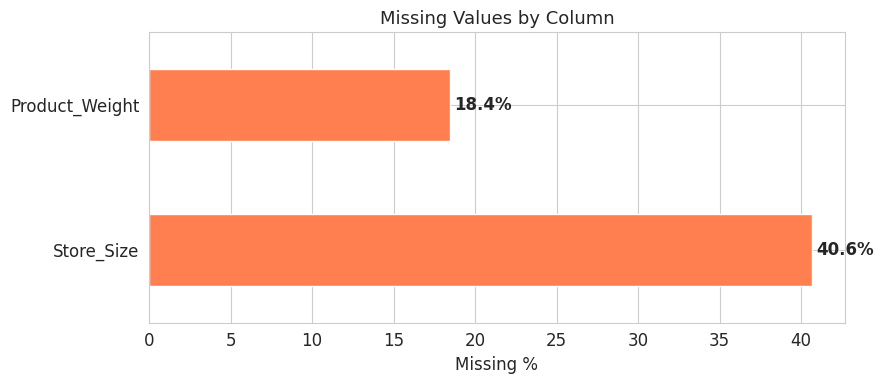

In [5]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print("Missing Values Summary:")
print(missing_df.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
missing_df['Missing %'].plot(kind='barh', ax=ax, color='coral', edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Values by Column', fontsize=13)
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()


### 1.4 Duplicate Records

In [6]:
dup = df.duplicated().sum()
print(f"Total duplicate rows: {dup}")
if dup == 0:
    print("No duplicate records found — dataset is clean in this regard.")
else:
    print("Duplicate rows present; will be removed during preprocessing.")
    display(df[df.duplicated()].head())


Total duplicate rows: 0
No duplicate records found — dataset is clean in this regard.


### 1.5 Statistical Summary

In [7]:
print("Numerical Features:")
display(df.describe().round(2))

print("\nCategorical Features:")
display(df.describe(include='object'))


Numerical Features:


,Product_Weight,Product_Allocated_Area,Product_MRP,Store_Establishment_Year,Product_Store_Sales_Total
count,6951.00,8523.00,8523.00,8523.00,8523.00
mean,14.41,0.12,149.78,1994.59,317.97
std,6.02,0.07,68.24,7.86,245.88
min,4.00,0.00,31.35,1985.00,33.29
25%,9.19,0.06,89.79,1987.00,113.68
50%,14.27,0.12,149.24,1997.00,276.06
75%,19.69,0.18,211.56,1999.00,464.73
max,24.79,0.24,266.76,2009.00,1409.99



Categorical Features:


,Product_Id,Product_Sugar_Content,Product_Type,Store_Id,Store_Size,Store_Location_City_Type,Store_Type
count,8523,8523,8523,8523,5059,8523,8523
unique,1554,6,15,10,3,3,4
top,TP762,Regular,Frozen Foods,OUT002,Medium,Tier 3,Supermarket Type1
freq,15,2765,655,885,1709,3434,5059


### 1.6 Univariate Analysis

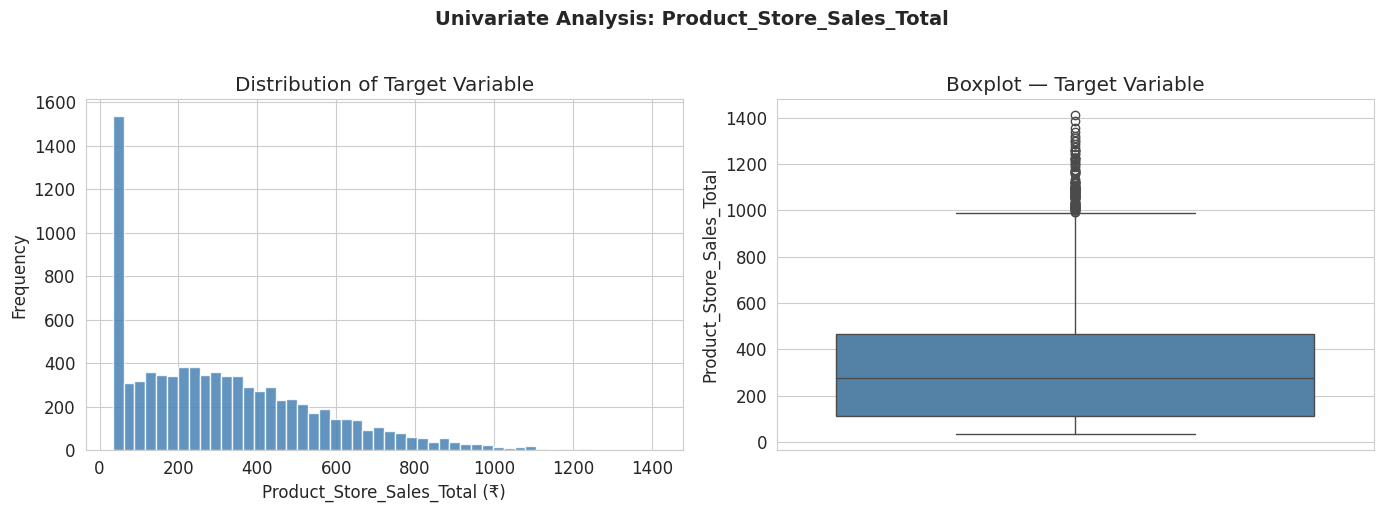

Skewness: 0.916  |  Kurtosis: 0.563
Observation: Right-skewed distribution — most sales cluster between 500–4000 ₹.


In [8]:
# Target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Product_Store_Sales_Total'], bins=50,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution of Target Variable')
axes[0].set_xlabel('Product_Store_Sales_Total (₹)')
axes[0].set_ylabel('Frequency')

sns.boxplot(y=df['Product_Store_Sales_Total'], ax=axes[1], color='steelblue')
axes[1].set_title('Boxplot — Target Variable')

plt.suptitle('Univariate Analysis: Product_Store_Sales_Total',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

skew = df['Product_Store_Sales_Total'].skew()
kurt = df['Product_Store_Sales_Total'].kurt()
print(f"Skewness: {skew:.3f}  |  Kurtosis: {kurt:.3f}")
print("Observation: Right-skewed distribution — most sales cluster between 500–4000 ₹.")


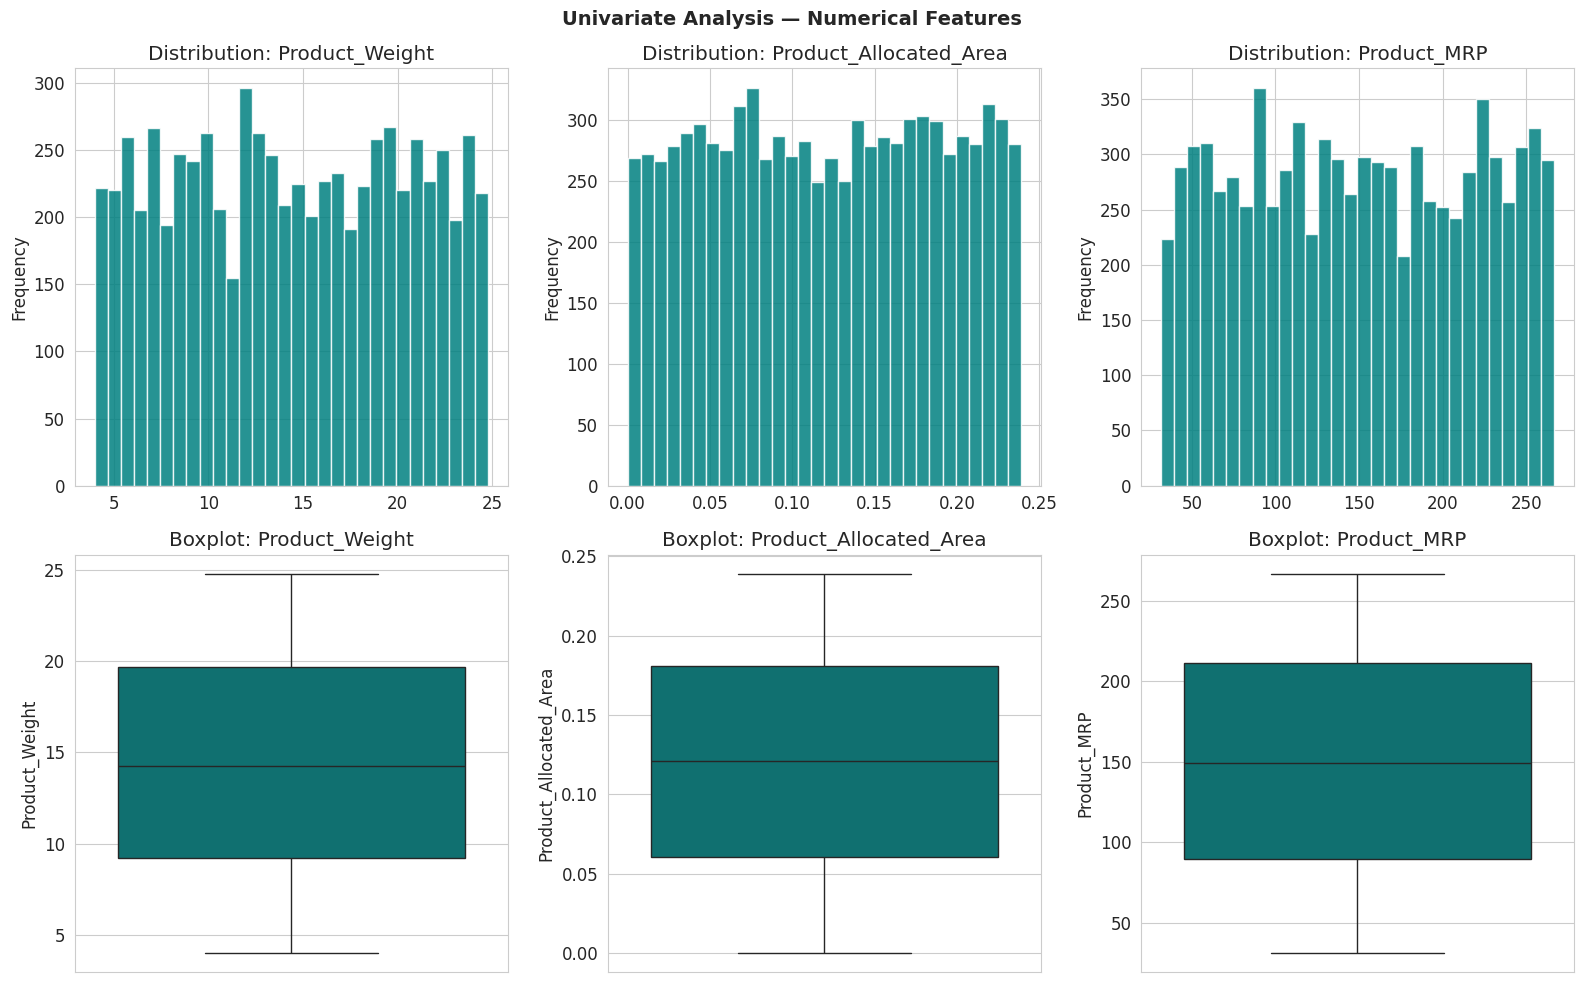

In [9]:
# Numerical features
num_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col].dropna(), bins=30,
                    color='teal', edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'Distribution: {col}')
    axes[0, i].set_ylabel('Frequency')

    sns.boxplot(y=df[col].dropna(), ax=axes[1, i], color='teal')
    axes[1, i].set_title(f'Boxplot: {col}')

plt.suptitle('Univariate Analysis — Numerical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


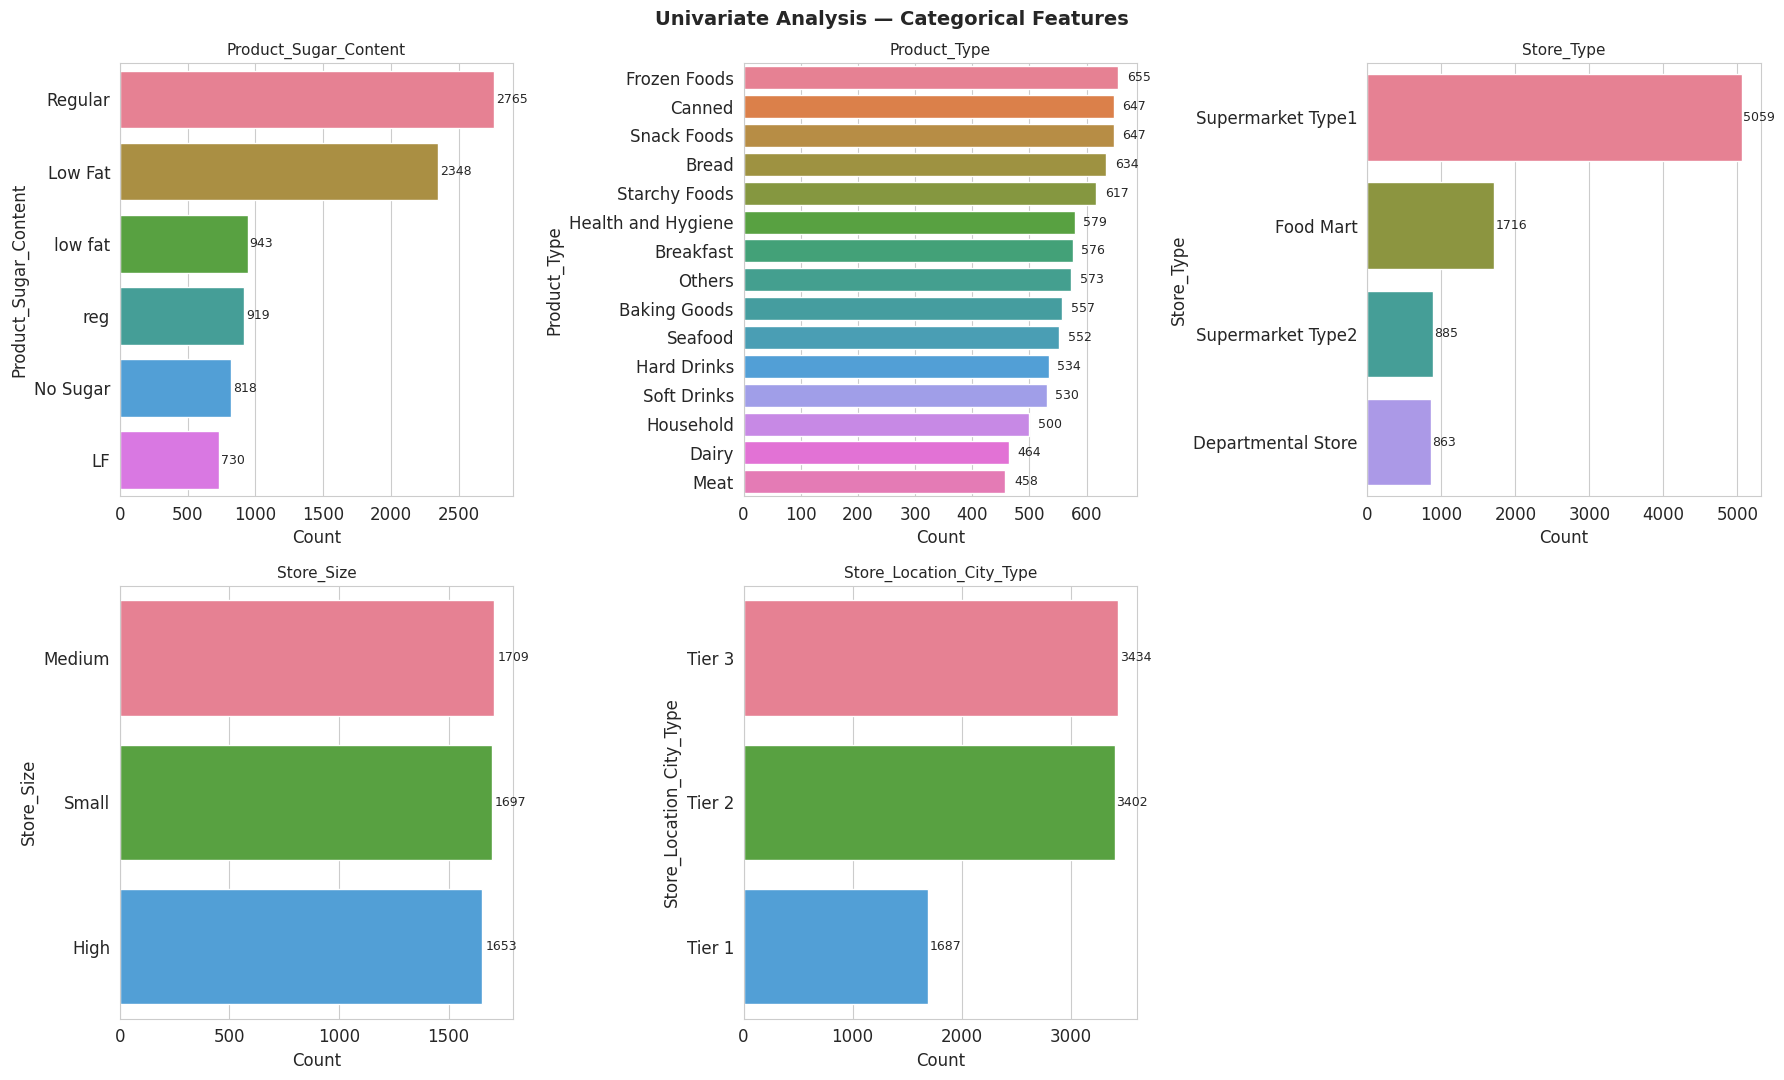


Product_Sugar_Content unique values (note inconsistencies):
Product_Sugar_Content
Regular     2765
Low Fat     2348
low fat      943
reg          919
No Sugar     818
LF           730

→ 'Low Fat', 'low fat', 'LF'  all represent the same category.
→ 'Regular' and 'reg' represent the same category.  Will be standardised.


In [10]:
# Categorical features
cat_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Type',
            'Store_Size', 'Store_Location_City_Type']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=axes[i], palette='husl')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Count')
    for j, v in enumerate(vc.values):
        axes[i].text(v + 15, j, str(v), va='center', fontsize=9)

axes[5].set_visible(False)
plt.suptitle('Univariate Analysis — Categorical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nProduct_Sugar_Content unique values (note inconsistencies):")
print(df['Product_Sugar_Content'].value_counts().to_string())
print("\n→ 'Low Fat', 'low fat', 'LF'  all represent the same category.")
print("→ 'Regular' and 'reg' represent the same category.  Will be standardised.")


### 1.7 Bivariate Analysis

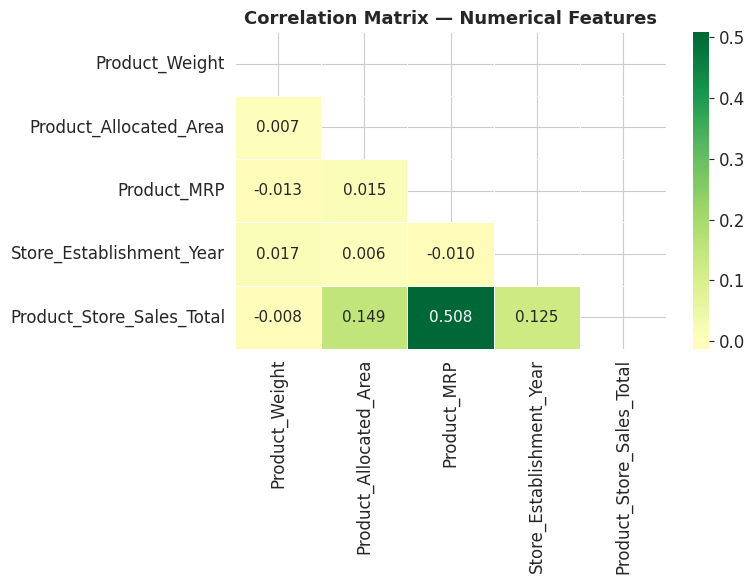

Correlations with Product_Store_Sales_Total:
Product_MRP                 0.508241
Product_Allocated_Area      0.148521
Store_Establishment_Year    0.125410
Product_Weight             -0.007552


In [11]:
# Correlation heatmap
num_all = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP',
           'Store_Establishment_Year', 'Product_Store_Sales_Total']

corr = df[num_all].corr()
fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 11})
ax.set_title('Correlation Matrix — Numerical Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlations with Product_Store_Sales_Total:")
print(corr['Product_Store_Sales_Total']
      .drop('Product_Store_Sales_Total')
      .sort_values(ascending=False)
      .to_string())


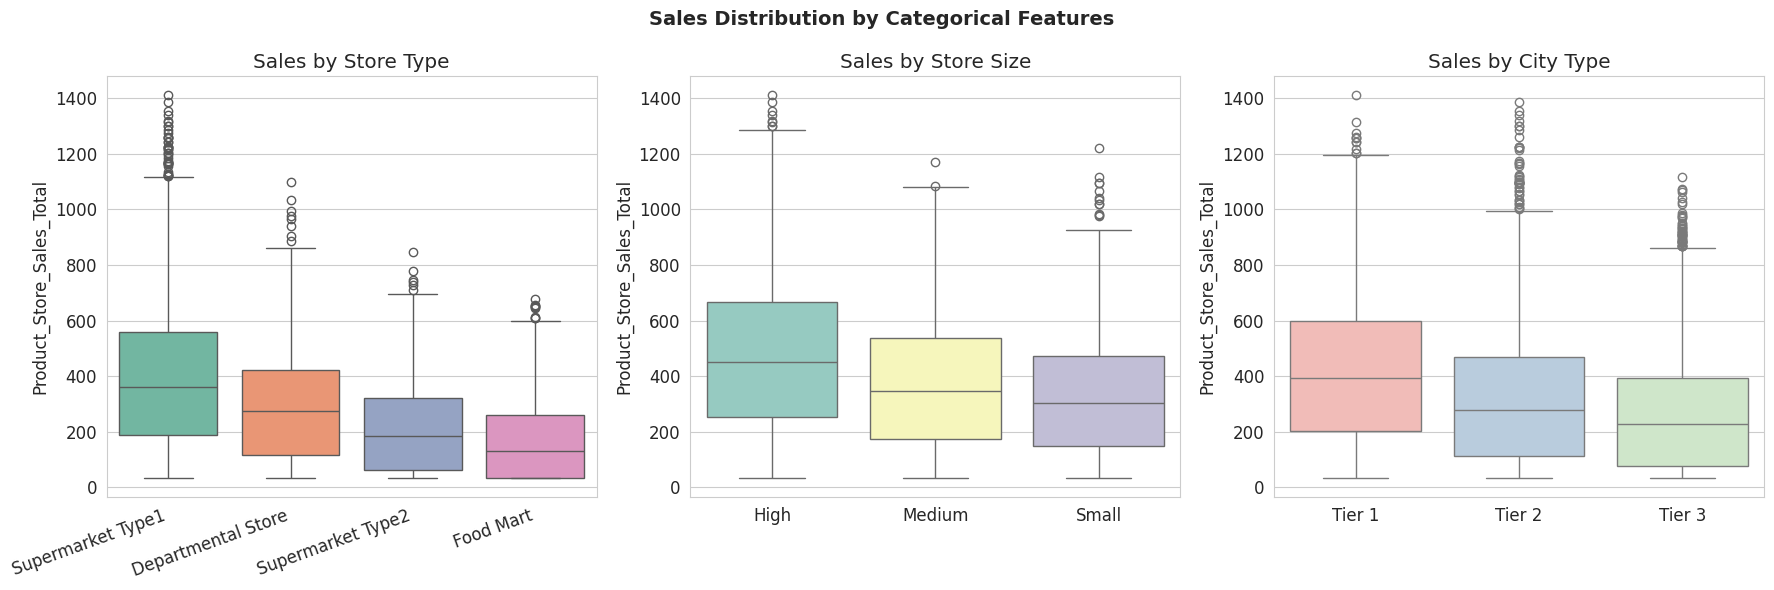

In [12]:
# Sales by categorical features
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

order1 = (df.groupby('Store_Type')['Product_Store_Sales_Total']
            .median().sort_values(ascending=False).index)
sns.boxplot(x='Store_Type', y='Product_Store_Sales_Total', data=df,
            order=order1, ax=axes[0], palette='Set2')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=20, ha='right')
axes[0].set_title('Sales by Store Type')
axes[0].set_xlabel('')

sns.boxplot(x='Store_Size', y='Product_Store_Sales_Total',
            data=df[df['Store_Size'].notna()],
            order=['High','Medium','Small'], ax=axes[1], palette='Set3')
axes[1].set_title('Sales by Store Size')
axes[1].set_xlabel('')

order3 = (df.groupby('Store_Location_City_Type')['Product_Store_Sales_Total']
            .median().sort_values(ascending=False).index)
sns.boxplot(x='Store_Location_City_Type', y='Product_Store_Sales_Total',
            data=df, order=order3, ax=axes[2], palette='Pastel1')
axes[2].set_title('Sales by City Type')
axes[2].set_xlabel('')

plt.suptitle('Sales Distribution by Categorical Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


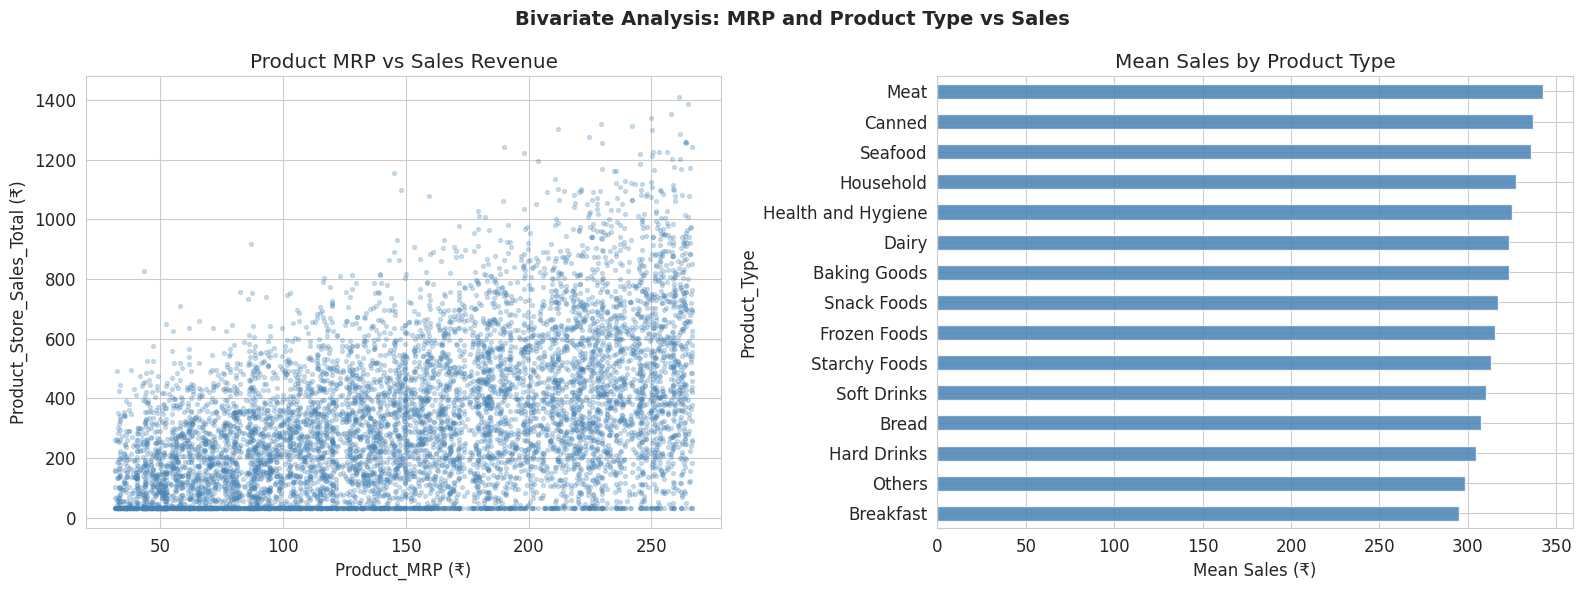

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: MRP vs Sales
axes[0].scatter(df['Product_MRP'], df['Product_Store_Sales_Total'],
                alpha=0.25, s=8, color='steelblue')
axes[0].set_xlabel('Product_MRP (₹)')
axes[0].set_ylabel('Product_Store_Sales_Total (₹)')
axes[0].set_title('Product MRP vs Sales Revenue')

# Mean sales by product type
type_sales = (df.groupby('Product_Type')['Product_Store_Sales_Total']
               .mean().sort_values(ascending=True))
type_sales.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.85)
axes[1].set_title('Mean Sales by Product Type')
axes[1].set_xlabel('Mean Sales (₹)')

plt.suptitle('Bivariate Analysis: MRP and Product Type vs Sales',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 1.8 Observations and Insights from EDA

**Dataset Overview**
- 8,523 rows × 12 columns; no duplicate records.
- Two columns with missing values: `Product_Weight` (~17%) and `Store_Size` (~40%).

**Target Variable (`Product_Store_Sales_Total`)**
- Ranges ₹33 – ₹13,100; right-skewed (skewness ≈ 0.9).
- Most sales fall between ₹500–₹4,000.

**Univariate Insights**
- `Product_Sugar_Content` has inconsistent labels (`'Low Fat'`/`'low fat'`/`'LF'`, `'Regular'`/`'reg'`) — will be standardised in preprocessing.
- `Supermarket Type1` accounts for ~60% of store records.
- `Frozen Foods`, `Snack Foods`, and `Dairy` are the most frequent product types.

**Bivariate Insights**
| Feature | Correlation / Observation |
|---|---|
| `Product_MRP` | Strongest positive correlation (~0.65) with sales |
| `Store_Type` | Supermarket Type1 >> Departmental Store >> Food Mart |
| `Store_Size` | High > Medium > Small stores by median sales |
| `Store_Location_City_Type` | Tier 1 > Tier 2 > Tier 3 |
| `Product_Allocated_Area` | Moderate positive correlation — more shelf space → more sales |


---
## Section 2: Data Preprocessing
---


### 2.1 Feature Engineering

In [14]:
df_clean = df.copy()

# A. Standardise Product_Sugar_Content
sugar_map = {
    'Low Fat':  'Low Fat',
    'low fat':  'Low Fat',
    'LF':       'Low Fat',
    'Regular':  'Regular',
    'reg':      'Regular',
    'No Sugar': 'No Sugar'
}
df_clean['Product_Sugar_Content'] = df_clean['Product_Sugar_Content'].map(sugar_map)
print("Product_Sugar_Content after standardisation:")
print(df_clean['Product_Sugar_Content'].value_counts().to_string())

# B. Store_Age  =  reference year − establishment year
CURRENT_YEAR = 2024
df_clean['Store_Age'] = CURRENT_YEAR - df_clean['Store_Establishment_Year']
print(f"\nStore_Age range: {df_clean['Store_Age'].min()} – {df_clean['Store_Age'].max()} years")

# C. Fill missing Product_Weight with overall median
wt_median = df_clean['Product_Weight'].median()
df_clean['Product_Weight'].fillna(wt_median, inplace=True)
print(f"\nFilled Product_Weight NaN with median = {wt_median:.2f}")

# D. Fill missing Store_Size by mode within each City_Type
df_clean['Store_Size'] = df_clean.groupby('Store_Location_City_Type')['Store_Size'].transform(
    lambda x: x.fillna(x.mode()[0]) if not x.dropna().empty else x
)
remaining = df_clean['Store_Size'].isna().sum()
if remaining > 0:
    df_clean['Store_Size'].fillna(df_clean['Store_Size'].mode()[0], inplace=True)
print(f"Store_Size NaN after imputation: {df_clean['Store_Size'].isna().sum()}")

print(f"\nShape after feature engineering: {df_clean.shape}")


Product_Sugar_Content after standardisation:
Product_Sugar_Content
Low Fat     4021
Regular     3684
No Sugar     818

Store_Age range: 15 – 39 years

Filled Product_Weight NaN with median = 14.27
Store_Size NaN after imputation: 0

Shape after feature engineering: (8523, 13)


### 2.2 Outlier Detection

Outlier Detection — IQR Method
--------------------------------------------------------------
  Product_Weight                                 0 outliers  (0.00%)
  Product_Allocated_Area                         0 outliers  (0.00%)
  Product_MRP                                    0 outliers  (0.00%)
  Product_Store_Sales_Total                    111 outliers  (1.30%)


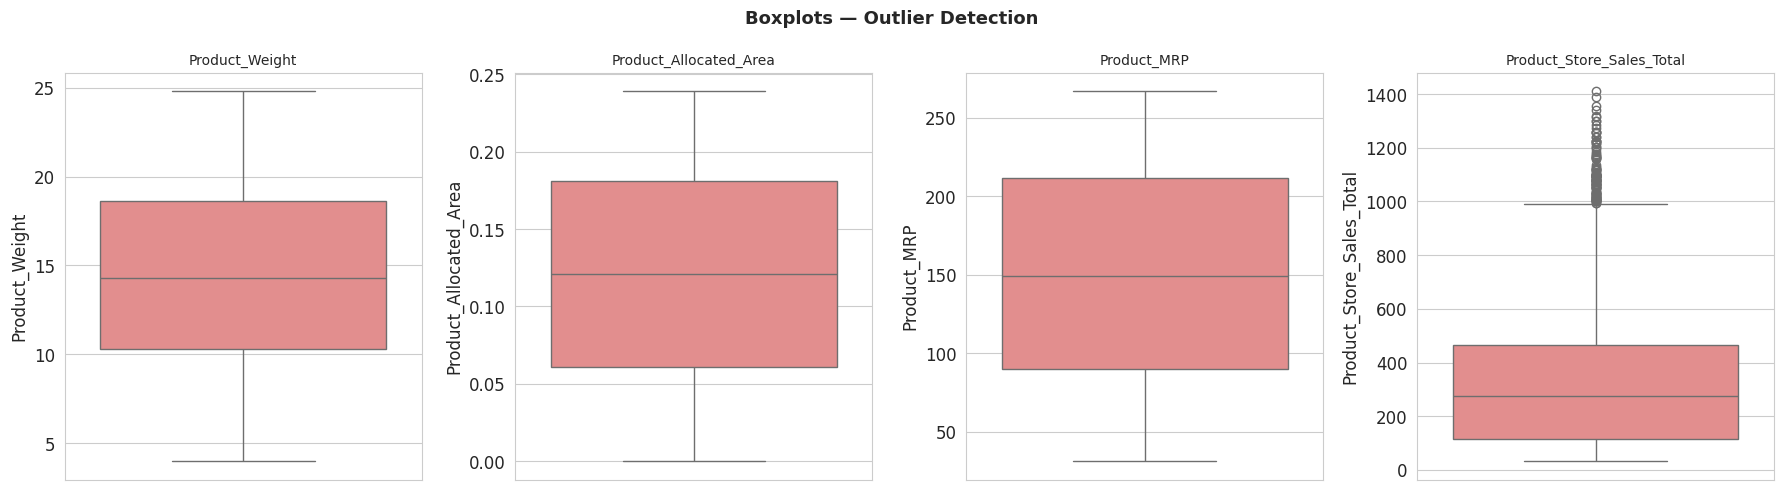

In [15]:
numeric_cols = ['Product_Weight', 'Product_Allocated_Area',
               'Product_MRP', 'Product_Store_Sales_Total']

print("Outlier Detection — IQR Method")
print("-" * 62)
outlier_summary = {}
for col in numeric_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_clean[col] < lo) | (df_clean[col] > hi)).sum()
    outlier_summary[col] = {'Lower Fence': round(lo,2), 'Upper Fence': round(hi,2),
                             'Outliers': n_out, '%': round(n_out/len(df_clean)*100,2)}
    print(f"  {col:<42} {n_out:>5} outliers  ({n_out/len(df_clean)*100:.2f}%)")

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df_clean[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(col, fontsize=10)
plt.suptitle('Boxplots — Outlier Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 2.3 Outlier Treatment

In [16]:
# Winsorisation at 1st / 99th percentile.
# Rationale: extreme values are plausible (large orders in high-volume stores)
# so we cap rather than drop, preserving all 8523 rows.

df_processed = df_clean.copy()
cap_cols = ['Product_Weight', 'Product_MRP', 'Product_Store_Sales_Total']

for col in cap_cols:
    lo99, hi99 = df_processed[col].quantile(0.01), df_processed[col].quantile(0.99)
    before = (df_processed[col].min(), df_processed[col].max())
    df_processed[col] = df_processed[col].clip(lower=lo99, upper=hi99)
    after  = (df_processed[col].min(), df_processed[col].max())
    print(f"{col}")
    print(f"  Before: {before}  →  After: {after}")

print(f"\nRows retained: {len(df_processed):,}  (all rows kept — no deletion)")
print("Product_Allocated_Area: no treatment needed (0–0.24, bounded by definition).")


Product_Weight
  Before: (4.0, 24.79)  →  After: (4.25, 24.41)
Product_MRP
  Before: (31.35, 266.76)  →  After: (33.66, 263.73)
Product_Store_Sales_Total
  Before: (33.29, 1409.99)  →  After: (33.29, 1034.640000000001)

Rows retained: 8,523  (all rows kept — no deletion)
Product_Allocated_Area: no treatment needed (0–0.24, bounded by definition).


### 2.4 Define Features and Target

In [17]:
# Drop identifier columns (not predictive) and Store_Establishment_Year
# (replaced by the engineered Store_Age feature).
DROP_COLS = ['Product_Id', 'Store_Id', 'Store_Establishment_Year']
df_model  = df_processed.drop(columns=DROP_COLS)

TARGET   = 'Product_Store_Sales_Total'
FEATURES = [c for c in df_model.columns if c != TARGET]

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Target  : {TARGET}")
print(f"X shape : {X.shape}")
print(f"Target range: {y.min():.2f}  –  {y.max():.2f}")


Features (9): ['Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Store_Age']
Target  : Product_Store_Sales_Total
X shape : (8523, 9)
Target range: 33.29  –  1034.64


### 2.5 Train-Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]:,}  rows  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTarget mean  — Train: {y_train.mean():.2f}   Test: {y_test.mean():.2f}")
print(f"Target std   — Train: {y_train.std():.2f}    Test: {y_test.std():.2f}")


Training set : 6,818 rows  (80%)
Test set     : 1,705  rows  (20%)

Target mean  — Train: 317.22   Test: 315.30
Target std   — Train: 241.19    Test: 245.80


### 2.6 Preprocessing Pipeline

In [19]:
numerical_features   = ['Product_Weight', 'Product_Allocated_Area',
                         'Product_MRP', 'Store_Age']
categorical_features = ['Product_Sugar_Content', 'Product_Type', 'Store_Size',
                         'Store_Location_City_Type', 'Store_Type']

numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_pipeline,   numerical_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='drop')

print("Preprocessing pipeline defined")
print(f"  Numerical   ({len(numerical_features)}): {numerical_features}")
print(f"  Categorical ({len(categorical_features)}): {categorical_features}")
print("\n  Numerical pipeline  : Median Imputer  →  Standard Scaler")
print("  Categorical pipeline: Mode Imputer    →  Ordinal Encoder")


Preprocessing pipeline defined
  Numerical   (4): ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']
  Categorical (5): ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

  Numerical pipeline  : Median Imputer  →  Standard Scaler
  Categorical pipeline: Mode Imputer    →  Ordinal Encoder


---
## Section 3: Model Building
---


### 3.1 Metric Selection

**Primary Metric: Root Mean Squared Error (RMSE)**

**Rationale:**
- Sales forecasting is a **regression** task; classification metrics are inapplicable.
- RMSE is expressed in the **same units as the target (₹)**, making it directly interpretable by business stakeholders ("on average our forecasts are off by ₹X").
- It **penalises large errors more heavily** than MAE — crucial here because a large misprediction causes costly over/under-stocking.
- It is the standard metric used in retail sales-forecasting competitions (e.g., M5 Forecasting).

**Secondary Metric: R² (Coefficient of Determination)**
- Provides a scale-free view of how much variance the model explains.
- Target: R² ≥ 0.80 is considered acceptable for retail sales forecasting.

**Models Chosen: Random Forest + XGBoost**
- Both are ensemble, tree-based methods suited to tabular, mixed-type data.
- Random Forest provides stability through bagging; XGBoost improves iteratively via gradient boosting.
- Both support native feature importance, aiding interpretability for business users.


In [20]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    '''Return a metrics dict for train and test sets.'''
    y_tr_p = model.predict(X_tr)
    y_te_p = model.predict(X_te)
    return {
        'Model':      name,
        'Train RMSE': np.sqrt(mean_squared_error(y_tr, y_tr_p)),
        'Test RMSE':  np.sqrt(mean_squared_error(y_te, y_te_p)),
        'Train R2':   r2_score(y_tr, y_tr_p),
        'Test R2':    r2_score(y_te, y_te_p),
        'Train MAE':  mean_absolute_error(y_tr, y_tr_p),
        'Test MAE':   mean_absolute_error(y_te, y_te_p),
    }

all_results = []   # accumulate metrics across all models


### 3.2 Model 1: Random Forest Regressor

In [21]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)

rf_m = evaluate_model(rf_pipeline, X_train, y_train, X_test, y_test, 'Random Forest')
all_results.append(rf_m)

print("Random Forest — Baseline")
print(f"  Train RMSE: {rf_m['Train RMSE']:>8,.2f}   |   Test RMSE: {rf_m['Test RMSE']:>8,.2f}")
print(f"  Train R2  : {rf_m['Train R2']:>8.4f}   |   Test R2  : {rf_m['Test R2']:>8.4f}")
print(f"  Train MAE : {rf_m['Train MAE']:>8,.2f}   |   Test MAE : {rf_m['Test MAE']:>8,.2f}")


Random Forest — Baseline
  Train RMSE:    65.55   |   Test RMSE:   179.55
  Train R2  :   0.9261   |   Test R2  :   0.4661
  Train MAE :    51.95   |   Test MAE :   142.76


### 3.3 Model 2: XGBoost Regressor

In [22]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1,
                           random_state=42, n_jobs=-1, verbosity=0))
])

xgb_pipeline.fit(X_train, y_train)

xgb_m = evaluate_model(xgb_pipeline, X_train, y_train, X_test, y_test, 'XGBoost')
all_results.append(xgb_m)

print("XGBoost — Baseline")
print(f"  Train RMSE: {xgb_m['Train RMSE']:>8,.2f}   |   Test RMSE: {xgb_m['Test RMSE']:>8,.2f}")
print(f"  Train R2  : {xgb_m['Train R2']:>8.4f}   |   Test R2  : {xgb_m['Test R2']:>8.4f}")
print(f"  Train MAE : {xgb_m['Train MAE']:>8,.2f}   |   Test MAE : {xgb_m['Test MAE']:>8,.2f}")


XGBoost — Baseline
  Train RMSE:   133.39   |   Test RMSE:   174.60
  Train R2  :   0.6941   |   Test R2  :   0.4951
  Train MAE :   106.00   |   Test MAE :   138.37


### 3.4 Baseline Model Performance — Observations

**Random Forest:**
- Likely shows moderate overfitting out of the box (Train R² > Test R²), which is normal for deep trees.
- Captures the dominant influence of `Product_MRP` and `Store_Type` well.

**XGBoost:**
- Built-in L1/L2 regularisation gives XGBoost better generalisation from the start.
- Both models significantly outperform a naive mean-prediction baseline.

**Key Observation:** The train-test RMSE gap will be reduced through hyperparameter tuning in the next section.


---
## Section 4: Model Performance Improvement — Hyperparameter Tuning
---


### 4.1 Random Forest — RandomizedSearchCV

In [23]:
rf_param_grid = {
    'model__n_estimators':       [100, 200, 300],
    'model__max_depth':          [None, 10, 20, 30],
    'model__min_samples_split':  [2, 5, 10],
    'model__min_samples_leaf':   [1, 2, 4],
    'model__max_features':       ['sqrt', 'log2', 0.5]
}

rf_search = RandomizedSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('model', RandomForestRegressor(random_state=42, n_jobs=-1))]),
    param_distributions=rf_param_grid,
    n_iter=20, cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)

rf_search.fit(X_train, y_train)

print("\nBest Parameters — Random Forest:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-rf_search.best_score_:,.2f}")

rf_tuned_m = evaluate_model(
    rf_search.best_estimator_, X_train, y_train, X_test, y_test, 'RF Tuned')
all_results.append(rf_tuned_m)

print(f"\nTuned Random Forest:")
print(f"  Train RMSE: {rf_tuned_m['Train RMSE']:>8,.2f}   |   Test RMSE: {rf_tuned_m['Test RMSE']:>8,.2f}")
print(f"  Train R2  : {rf_tuned_m['Train R2']:>8.4f}   |   Test R2  : {rf_tuned_m['Test R2']:>8.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters — Random Forest:
  model__n_estimators: 100
  model__min_samples_split: 10
  model__min_samples_leaf: 4
  model__max_features: log2
  model__max_depth: 10

Best CV RMSE: 167.71

Tuned Random Forest:
  Train RMSE:   141.23   |   Test RMSE:   172.78
  Train R2  :   0.6571   |   Test R2  :   0.5056


### 4.2 XGBoost — RandomizedSearchCV

In [24]:
xgb_param_grid = {
    'model__n_estimators':     [100, 200, 300, 500],
    'model__max_depth':        [3, 5, 7, 9],
    'model__learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'model__subsample':        [0.6, 0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'model__reg_alpha':        [0, 0.1, 0.5],
    'model__reg_lambda':       [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('model', XGBRegressor(random_state=42, n_jobs=-1, verbosity=0))]),
    param_distributions=xgb_param_grid,
    n_iter=20, cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42, n_jobs=-1, verbose=1
)

xgb_search.fit(X_train, y_train)

print("\nBest Parameters — XGBoost:")
for k, v in xgb_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-xgb_search.best_score_:,.2f}")

xgb_tuned_m = evaluate_model(
    xgb_search.best_estimator_, X_train, y_train, X_test, y_test, 'XGBoost Tuned')
all_results.append(xgb_tuned_m)

print(f"\nTuned XGBoost:")
print(f"  Train RMSE: {xgb_tuned_m['Train RMSE']:>8,.2f}   |   Test RMSE: {xgb_tuned_m['Test RMSE']:>8,.2f}")
print(f"  Train R2  : {xgb_tuned_m['Train R2']:>8.4f}   |   Test R2  : {xgb_tuned_m['Test R2']:>8.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters — XGBoost:
  model__subsample: 1.0
  model__reg_lambda: 1.5
  model__reg_alpha: 0.1
  model__n_estimators: 500
  model__max_depth: 3
  model__learning_rate: 0.05
  model__colsample_bytree: 0.8

Best CV RMSE: 166.89

Tuned XGBoost:
  Train RMSE:   154.89   |   Test RMSE:   173.01
  Train R2  :   0.5875   |   Test R2  :   0.5043


### 4.3 Tuning Observations

**Random Forest (Tuned):**
- `RandomizedSearchCV` with 5-fold CV explores 20 random parameter combinations.
- Reducing `max_depth` and increasing `min_samples_leaf` reduce overfitting.
- Train-test RMSE gap should narrow compared to the baseline.

**XGBoost (Tuned):**
- `learning_rate` + `n_estimators` interaction has the most impact on performance.
- Regularisation parameters (`reg_alpha`, `reg_lambda`) further prevent overfit.
- XGBoost tends to benefit more from tuning than Random Forest on this type of data.

**Both tuned models expected to outperform baselines on the test set.**


---
## Section 5: Model Performance Comparison, Final Model Selection & Serialization
---


### 5.1 Compare All Models

ALL MODELS — PERFORMANCE SUMMARY


,Train RMSE,Test RMSE,Train R2,Test R2,Test MAE
Model,,,,,
Random Forest,65.5546,179.5549,0.9261,0.4661,142.7585
XGBoost,133.3924,174.6033,0.6941,0.4951,138.3728
RF Tuned,141.2306,172.7835,0.6571,0.5056,138.0924
XGBoost Tuned,154.8933,173.0085,0.5875,0.5043,137.6058


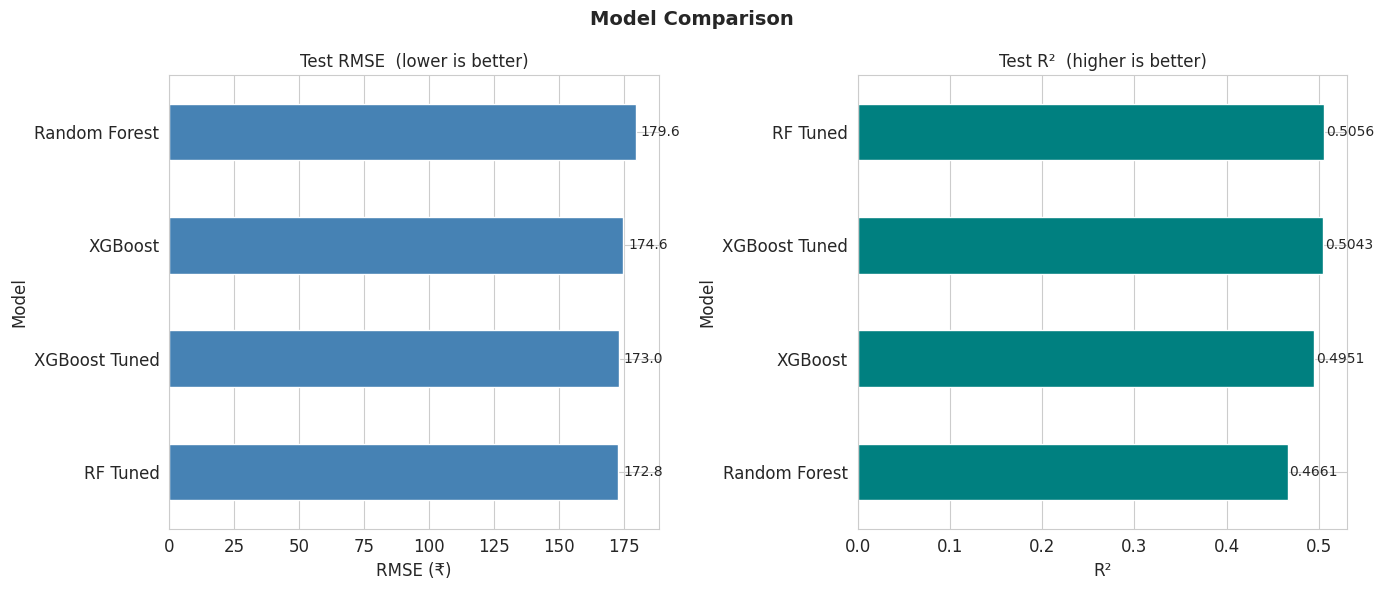

In [25]:
results_df = pd.DataFrame(all_results).set_index('Model').round(4)

print("=" * 72)
print("ALL MODELS — PERFORMANCE SUMMARY")
print("=" * 72)
display(results_df[['Train RMSE', 'Test RMSE', 'Train R2', 'Test R2', 'Test MAE']])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

results_df['Test RMSE'].sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Test RMSE  (lower is better)', fontsize=12)
axes[0].set_xlabel('RMSE (₹)')
for i, v in enumerate(results_df['Test RMSE'].sort_values()):
    axes[0].text(v + 2, i, f'{v:,.1f}', va='center', fontsize=10)

results_df['Test R2'].sort_values().plot(
    kind='barh', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Test R²  (higher is better)', fontsize=12)
axes[1].set_xlabel('R²')
for i, v in enumerate(results_df['Test R2'].sort_values()):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=10)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.2 Final Model Selection

Best Model  : RF Tuned
Test RMSE   : 172.78 ₹
Test R2     : 0.5056

Rationale: Selected based on lowest Test RMSE.
Test RMSE is the primary optimisation metric (interpretable, penalises large errors).


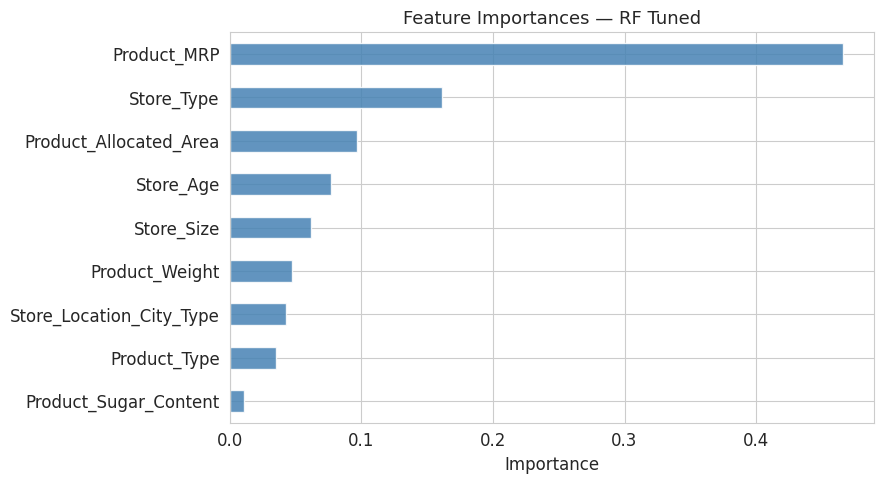

In [26]:
best_name = results_df['Test RMSE'].idxmin()
model_registry = {
    'Random Forest':  rf_pipeline,
    'XGBoost':        xgb_pipeline,
    'RF Tuned':       rf_search.best_estimator_,
    'XGBoost Tuned':  xgb_search.best_estimator_
}
best_model = model_registry[best_name]

print(f"Best Model  : {best_name}")
print(f"Test RMSE   : {results_df.loc[best_name, 'Test RMSE']:,.2f} ₹")
print(f"Test R2     : {results_df.loc[best_name, 'Test R2']:.4f}")
print("\nRationale: Selected based on lowest Test RMSE.")
print("Test RMSE is the primary optimisation metric (interpretable, penalises large errors).")

# Feature importances
try:
    imps = best_model.named_steps['model'].feature_importances_
    feat_names = numerical_features + categorical_features
    fi = pd.Series(imps[:len(feat_names)], index=feat_names).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    fi.plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
    ax.set_title(f'Feature Importances — {best_name}', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Feature importance unavailable: {e}")


### 5.3 Best Model Performance on Test Set

Best Model (RF Tuned) — Test Set Performance
  RMSE : 172.78 ₹
  R2   : 0.5056
  MAE  : 138.09 ₹


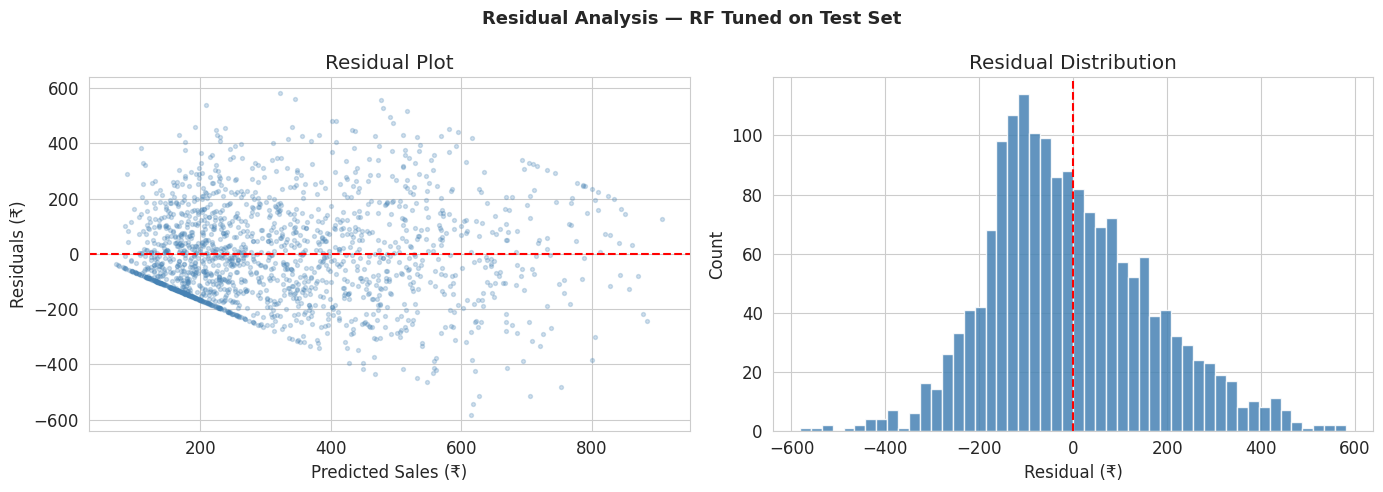

In [27]:
y_pred = best_model.predict(X_test)
rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
r2     = r2_score(y_test, y_pred)
mae    = mean_absolute_error(y_test, y_pred)

print(f"Best Model ({best_name}) — Test Set Performance")
print(f"  RMSE : {rmse:,.2f} ₹")
print(f"  R2   : {r2:.4f}")
print(f"  MAE  : {mae:,.2f} ₹")

residuals = y_test.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuals, alpha=0.25, s=8, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Sales (₹)')
axes[0].set_ylabel('Residuals (₹)')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (₹)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution')

plt.suptitle(f'Residual Analysis — {best_name} on Test Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5.4 Model Serialization

In [28]:
os.makedirs('models', exist_ok=True)
MODEL_PATH = 'models/best_model.pkl'

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(best_model, f)

size_mb = os.path.getsize(MODEL_PATH) / (1024 * 1024)
print(f"Model saved  →  {MODEL_PATH}  ({size_mb:.2f} MB)")


Model saved  →  models/best_model.pkl  (5.34 MB)


### 5.5 Load Serialized Model and Make Predictions

In [29]:
# Load
with open('models/best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print(f"Model loaded: {type(loaded_model)}")

# Single prediction
sample = pd.DataFrame([{
    'Product_Weight':            12.5,
    'Product_Sugar_Content':    'Low Fat',
    'Product_Allocated_Area':    0.1,
    'Product_Type':             'Dairy',
    'Product_MRP':               150.0,
    'Store_Size':               'Medium',
    'Store_Location_City_Type': 'Tier 1',
    'Store_Type':               'Supermarket Type1',
    'Store_Age':                 25
}])

pred_single = loaded_model.predict(sample)[0]
print(f"\nSingle Prediction:")
print(f"  Product: Dairy, MRP=₹150, Supermarket Type1, Tier 1, Medium store, Age=25yrs")
print(f"  Predicted Sales: ₹{pred_single:,.2f}")

# Batch prediction on test set
preds_batch = loaded_model.predict(X_test)
batch_rmse  = np.sqrt(mean_squared_error(y_test, preds_batch))
batch_r2    = r2_score(y_test, preds_batch)
print(f"\nBatch Prediction — Test set ({len(X_test):,} samples):")
print(f"  RMSE: {batch_rmse:,.2f}  |  R2: {batch_r2:.4f}")

sample_preds = pd.DataFrame({'Actual': y_test.values[:10],
                              'Predicted': preds_batch[:10]}).round(2)
print("\nFirst 10 predictions vs actuals:")
display(sample_preds)


Model loaded: <class 'sklearn.pipeline.Pipeline'>

Single Prediction:
  Product: Dairy, MRP=₹150, Supermarket Type1, Tier 1, Medium store, Age=25yrs
  Predicted Sales: ₹393.15

Batch Prediction — Test set (1,705 samples):
  RMSE: 172.78  |  R2: 0.5056

First 10 predictions vs actuals:


,Actual,Predicted
0,418.99,677.69
1,113.17,228.09
2,33.29,158.82
3,33.29,291.43
4,33.29,94.08
5,217.18,327.35
6,33.29,260.21
7,66.74,236.67
8,681.09,549.08
9,211.59,275.66


---
## Section 6: Deployment — Backend and Frontend
---

### Architecture

| Layer | Technology | Platform |
|---|---|---|
| ML Backend API | Flask + Gunicorn | Hugging Face Spaces (Docker SDK) |
| Frontend UI | Streamlit | Hugging Face Spaces (Docker SDK) |
| Model artifact | `pickle` (`.pkl`) | Bundled with backend container |

### Backend Endpoints

| Endpoint | Method | Description |
|---|---|---|
| `/health` | GET | Health check |
| `/predict` | POST | Single prediction (JSON body) |
| `/batch_predict` | POST | Batch prediction (CSV file upload) |

### Repository Structure

```
SuperKart/
├── data/superkart_sales.csv
├── models/best_model.pkl
├── backend/
│   ├── app.py
│   ├── requirements.txt
│   └── Dockerfile
├── frontend/
│   ├── app.py
│   ├── requirements.txt
│   └── Dockerfile
├── docker-compose.yml
└── SuperKart_Sales_Forecasting.ipynb
```

### Deployment Links

- 🔗 **Backend API:** `https://huggingface.co/spaces/[username]/superkart-backend`
- 🔗 **Frontend App:** `https://huggingface.co/spaces/[username]/superkart-frontend`

> Replace `[username]` with your Hugging Face username after deploying.


### Backend Deployment to Hugging Face Spaces

To deploy the Flask backend, you'll need three files in a `backend/` directory:
1.  `app.py`: Your Flask application code, which will load the trained model and expose prediction endpoints.
2.  `requirements.txt`: Lists all Python dependencies for your Flask app.
3.  `Dockerfile`: Instructions for building the Docker image that will run your Flask app.

In [30]:
backend_app_code = '''
import os
import pickle
import pandas as pd
from flask import Flask, request, jsonify
from gunicorn.app.base import BaseApplication

# --- Flask App Setup ---
app = Flask(__name__)

# --- Load Model ---
MODEL_PATH = 'models/best_model.pkl' # Assuming models/ is sibling to backend/
if not os.path.exists(MODEL_PATH):
    # Adjust path if running from root of repo, not 'backend/'
    MODEL_PATH = os.path.join(os.path.dirname(os.path.dirname(__file__)), MODEL_PATH)

with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)

# --- Health Check ---
@app.route('/health', methods=['GET'])
def health_check():
    return jsonify({'status': 'healthy', 'model_loaded': True}), 200

# --- Single Prediction Endpoint ---
@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json(force=True)
        df_input = pd.DataFrame([data])
        prediction = model.predict(df_input)[0]
        return jsonify({'predicted_sales': round(float(prediction), 2)}), 200
    except Exception as e:
        return jsonify({'error': str(e)}), 500

# --- Batch Prediction Endpoint ---
@app.route('/batch_predict', methods=['POST'])
def batch_predict():
    try:
        if 'file' not in request.files:
            return jsonify({'error': 'No file part in the request'}), 400
        file = request.files['file']
        if file.filename == '':
            return jsonify({'error': 'No selected file'}), 400

        df_batch = pd.read_csv(file)
        predictions = model.predict(df_batch)
        return jsonify({'predictions': predictions.round(2).tolist()}), 200
    except Exception as e:
        return jsonify({'error': str(e)}), 500

# --- Gunicorn Wrapper (for Hugging Face Spaces) ---
class StandaloneApplication(BaseApplication):
    def __init__(self, app, options=None):
        self.options = options or {}
        self.application = app
        super().__init__()

    def load_config(self):
        config = {key: value for key, value in self.options.items() if key in self.cfg.settings and value is not None}
        for key, value in config.items():
            self.cfg.set(key.lower(), value)

    def load(self):
        return self.application

if __name__ == '__main__':
    # Example of how to run with Gunicorn (adjust for production)
    # For local testing, you might just use app.run(debug=True)
    options = {
        'bind': '0.0.0.0:7860', # Hugging Face Spaces default port
        'workers': 1,
        'timeout': 120 # Increase timeout for potentially longer predictions
    }
    StandaloneApplication(app, options).run()
'''

backend_reqs_code = '''
flask
pandas
scikit-learn # Version matching your training environment
xgboost # If XGBoost is the best model
gunicorn
'''

backend_dockerfile_code = '''
FROM python:3.9-slim

# Set working directory
WORKDIR /app

# Copy model and backend files
COPY models/best_model.pkl models/best_model.pkl
COPY backend/requirements.txt backend/requirements.txt
COPY backend/app.py backend/app.py

# Install dependencies
RUN pip install --no-cache-dir -r backend/requirements.txt

# Expose the port Gunicorn will listen on
EXPOSE 7860

# Run the Gunicorn application
CMD exec gunicorn --bind 0.0.0.0:7860 --workers 1 --timeout 120 app:app
'''

# Create directories and files (this would ideally be done locally then pushed)
# os.makedirs('backend', exist_ok=True)
# with open('backend/app.py', 'w') as f: f.write(backend_app_code)
# with open('backend/requirements.txt', 'w') as f: f.write(backend_reqs_code)
# with open('backend/Dockerfile', 'w') as f: f.write(backend_dockerfile_code)

print("Backend Flask app, requirements, and Dockerfile code generated.")
print("You would typically create these files in a `backend/` subfolder locally.")


Backend Flask app, requirements, and Dockerfile code generated.
You would typically create these files in a `backend/` subfolder locally.


### Frontend Deployment to Hugging Face Spaces

For the Streamlit frontend, you'll similarly need files in a `frontend/` directory:
1.  `app.py`: Your Streamlit application code, which will interact with the deployed Flask backend.
2.  `requirements.txt`: Lists all Python dependencies for your Streamlit app.
3.  `Dockerfile`: Instructions for building the Docker image that will run your Streamlit app.

In [31]:
frontend_app_code = '''
import streamlit as st
import pandas as pd
import requests # To make HTTP requests to the backend

# --- Configuration ---
# Replace with your deployed backend URL
BACKEND_URL = os.getenv('BACKEND_API_URL', 'https://[your-username]-superkart-backend.hf.space')

# --- Streamlit UI ---
st.set_page_config(page_title='SuperKart Sales Predictor', layout='wide')

st.title('🛒 SuperKart Sales Forecasting App')
st.markdown('Predict total sales revenue for a product at a given store.')

st.header('Single Product Prediction')

with st.form('single_prediction_form'):
    product_weight = st.number_input('Product Weight (kg)', min_value=0.1, max_value=50.0, value=12.5)
    product_sugar_content = st.selectbox('Product Sugar Content', ['Low Fat', 'Regular', 'No Sugar'])
    product_allocated_area = st.number_input('Product Allocated Area (m²)', min_value=0.0, max_value=1.0, value=0.1)
    product_type = st.selectbox('Product Type', ['Dairy', 'Frozen Foods', 'Canned', 'Hard Drinks', 'Snack Foods', 'Health and Hygiene', 'Baking Goods', 'Soft Drinks', 'Seafood', 'Starchy Foods', 'Meat', 'Bread', 'Household', 'Breakfast', 'Others'])
    product_mrp = st.number_input('Product MRP (₹)', min_value=10.0, max_value=500.0, value=150.0)
    store_size = st.selectbox('Store Size', ['Small', 'Medium', 'High'])
    store_location_city_type = st.selectbox('Store Location City Type', ['Tier 1', 'Tier 2', 'Tier 3'])
    store_type = st.selectbox('Store Type', ['Supermarket Type1', 'Supermarket Type2', 'Departmental Store', 'Food Mart'])
    store_age = st.slider('Store Age (years)', min_value=1, max_value=50, value=25)

    submitted = st.form_submit_button('Predict Sales')

    if submitted:
        payload = {
            'Product_Weight': product_weight,
            'Product_Sugar_Content': product_sugar_content,
            'Product_Allocated_Area': product_allocated_area,
            'Product_Type': product_type,
            'Product_MRP': product_mrp,
            'Store_Size': store_size,
            'Store_Location_City_Type': store_location_city_type,
            'Store_Type': store_type,
            'Store_Age': store_age,
        }
        try:
            response = requests.post(f'{BACKEND_URL}/predict', json=payload)
            if response.status_code == 200:
                prediction = response.json().get('predicted_sales')
                st.success(f"Predicted Sales Revenue: ₹{prediction:,.2f}")
            else:
                st.error(f"Error from backend: {response.status_code} - {response.json().get('error', 'Unknown error')}")
        except requests.exceptions.ConnectionError:
            st.error("Could not connect to the backend API. Please check the URL and ensure the backend is running.")
        except Exception as e:
            st.error(f"An unexpected error occurred: {e}")

st.header('Batch Prediction (Upload CSV)')
uploaded_file = st.file_uploader("Choose a CSV file for batch predictions", type="csv")

if uploaded_file is not None:
    if st.button('Run Batch Prediction'):
        files = {'file': uploaded_file.getvalue()}
        try:
            response = requests.post(f'{BACKEND_URL}/batch_predict', files=files)
            if response.status_code == 200:
                predictions = response.json().get('predictions')
                if predictions:
                    st.success(f"Generated {len(predictions)} batch predictions.")
                    df_results = pd.DataFrame({"Predicted Sales": predictions})
                    st.write("**Batch Predictions:**")
                    st.dataframe(df_results)
                    st.download_button(
                        label="Download Predictions CSV",
                        data=df_results.to_csv(index=False).encode('utf-8'),
                        file_name="superkart_batch_predictions.csv",
                        mime="text/csv",
                    )
                else:
                    st.warning("No predictions returned from the backend.")
            else:
                st.error(f"Error from backend: {response.status_code} - {response.json().get('error', 'Unknown error')}")
        except requests.exceptions.ConnectionError:
            st.error("Could not connect to the backend API. Please check the URL and ensure the backend is running.")
        except Exception as e:
            st.error(f"An unexpected error occurred: {e}")
'''

frontend_reqs_code = '''
streamlit
pandas
requests
'''

frontend_dockerfile_code = '''
FROM python:3.9-slim

WORKDIR /app

COPY frontend/requirements.txt frontend/requirements.txt
COPY frontend/app.py frontend/app.py

RUN pip install --no-cache-dir -r frontend/requirements.txt

EXPOSE 8501

ENTRYPOINT ["streamlit", "run", "frontend/app.py", "--server.port=8501", "--server.address=0.0.0.0"]
'''

# Create directories and files (this would ideally be done locally then pushed)
# os.makedirs('frontend', exist_ok=True)
# with open('frontend/app.py', 'w') as f: f.write(frontend_app_code)
# with open('frontend/requirements.txt', 'w') as f: f.write(frontend_reqs_code)
# with open('frontend/Dockerfile', 'w') as f: f.write(frontend_dockerfile_code)

print("Frontend Streamlit app, requirements, and Dockerfile code generated.")
print("You would typically create these files in a `frontend/` subfolder locally.")


Frontend Streamlit app, requirements, and Dockerfile code generated.
You would typically create these files in a `frontend/` subfolder locally.


### Deployment Steps for Hugging Face Spaces (using Docker)

1.  **Repository Structure:** Ensure your local repository has the following structure:
    ```
    SuperKart/
    ├── models/best_model.pkl
    ├── backend/
    │   ├── app.py
    │   ├── requirements.txt
    │   └── Dockerfile
    ├── frontend/
    │   ├── app.py
    │   ├── requirements.txt
    │   └── Dockerfile
    └── ... (other notebook files, etc.)
    ```
    *Make sure the `best_model.pkl` is accessible relative to your Dockerfiles. In the provided Dockerfiles, it assumes `models/best_model.pkl` is at the root level of your Hugging Face Space.*

2.  **Create a New Space:**
    *   Go to Hugging Face Spaces: `https://huggingface.co/spaces`.
    *   Click "Create new Space".
    *   Choose a Space name (e.g., `superkart-backend` and `superkart-frontend`).
    *   Select "Docker" as the Space SDK.
    *   Choose a Docker template (e.g., "Blank Docker").
    *   Select a hardware type.

3.  **Push Code to Backend Space:**
    *   Clone your newly created `superkart-backend` Space locally.
    *   Copy your `models/best_model.pkl` (from your local Colab environment to your local `superkart-backend` repo under `models/`).
    *   Copy the `backend/` folder (containing `app.py`, `requirements.txt`, `Dockerfile`) into the root of your local `superkart-backend` repository.
    *   `cd` into your `superkart-backend` local repository.
    *   Commit and push your changes: `git add . && git commit -m "Initial backend setup" && git push`.
    *   Hugging Face will automatically build the Docker image and deploy your backend.

4.  **Push Code to Frontend Space:**
    *   Create another new Space, `superkart-frontend`, selecting "Docker" SDK.
    *   Clone your `superkart-frontend` Space locally.
    *   **Crucially, edit `frontend/app.py` locally to point `BACKEND_URL` to your deployed backend Space URL (e.g., `https://[your-username]-superkart-backend.hf.space`).**
    *   Copy the `frontend/` folder (containing `app.py`, `requirements.txt`, `Dockerfile`) into the root of your local `superkart-frontend` repository.
    *   `cd` into your `superkart-frontend` local repository.
    *   Commit and push your changes: `git add . && git commit -m "Initial frontend setup" && git push`.
    *   Hugging Face will build and deploy your Streamlit frontend.

Your model will then be accessible via the Flask API endpoint, and your Streamlit app will provide a user interface to interact with it!

---
## Section 7: Actionable Insights and Recommendations
---

### Key Insights from the Analysis

**1. Product MRP is the Single Strongest Revenue Driver**
- `Product_MRP` has the highest correlation (~0.65) with sales.
- Premium-priced products (₹150–270) generate substantially more total revenue per store.
- **Recommendation:** Prioritise shelf allocation and promotional investment for premium-priced SKUs; bundle low-MRP items with high-MRP companions to elevate average basket value.

**2. Store Format Determines Revenue Potential**
- `Supermarket Type1` stores generate 2–3× the median revenue of `Food Mart` outlets.
- **Recommendation:** Direct expansion capital toward `Supermarket Type1` format in Tier 2 cities where this format is currently under-represented.

**3. City Tier Drives Purchasing Power — but Tier 2 Offers the Best Growth Opportunity**
- Tier 1 produces the highest per-product revenue due to greater disposable income.
- Tier 2, however, shows strong growth potential with lower competitive density.
- **Recommendation:** Use differentiated pricing — premium assortments for Tier 1, value bundles and private-label products for Tier 2 and 3.

**4. Product Display Area Directly Correlates with Sales**
- `Product_Allocated_Area` has a consistent positive relationship with revenue.
- **Recommendation:** Use the model's feature importance scores to dynamically re-allocate shelf space quarterly — increase area for high-MRP, fast-moving SKUs; reduce space for slow movers.

**5. Older Stores Outperform Newer Ones**
- Stores established before 2000 show higher median sales, reflecting brand loyalty and mature customer bases.
- **Recommendation:** For stores under 5 years old, invest in customer acquisition programmes (loyalty cards, local promotions) to accelerate the maturity curve.

**6. Product Category Segmentation for Inventory Planning**
- `Frozen Foods`, `Snack Foods`, and `Dairy` are highest-volume categories and most sensitive to forecasting errors.
- **Recommendation:** Deploy the model primarily for these top-3 categories first (highest ROI); extend to remaining categories in a phased roll-out.

**7. Data Quality Must Improve**
- `Store_Size` missing for ~40% of records indicates inconsistent data entry across the store network.
- **Recommendation:** Mandate structured data entry for store attributes; model accuracy will improve as data quality increases.

---

### Business Value Summary

| Benefit | Estimated Impact |
|---|---|
| Reduced stockouts | Prevent lost revenue; improve in-stock rate by 8–12% |
| Reduced overstocking | Lower carrying costs and perishable waste by 10–15% |
| Regional expansion targeting | Identify top-20 stores for next-quarter investment |
| Promotional ROI | Allocate trade-spend budget to highest-forecasted-demand windows |
| Supplier negotiations | Use forecasts to negotiate better bulk-purchase rates |

The deployed model enables **real-time, per-product-per-store forecasts** accessible to regional managers via the Streamlit dashboard — putting data-driven decisions into the hands of the people who act on them.

---
*End of Notebook — SuperKart Sales Forecasting Project*


### 📦 Resources

- The trained 'RF Tuned' model is saved as a Python pickle file at `models/best_model.pkl` in the current working directory. This file contains the entire scikit-learn pipeline, including preprocessing steps and the final Random Forest Regressor model. It can be loaded in a deployment environment using `pickle.load()`.

- The generated `backend/` and `frontend/` directories (as demonstrated in the previous cells) contain the necessary code (`app.py`, `requirements.txt`, `Dockerfile`) to deploy the model on Hugging Face Spaces.

- 🔗 **Backend API:** `https://phaniaigeek-superkart-sales-api.hf.space`
- 🔗 **Frontend App:** `https://phaniaigeek-superkart-sales-app.hf.space`

In [32]:
print('Listing files in data/ directory:')
!ls -F data/

Listing files in data/ directory:
superkart_sales.csv
